# Director v3 Training Notebook – EfficientNet-B0

This notebook documents the training process for the Director v3 model (EfficientNet-B0) for geo-classification into 13 world regions.
We describe all major steps, explain our choices, and visualize the results, including the confusion matrix.


## Step 1. Introduction

The goal is to build a robust classifier that assigns each image to one of 13 broad geographic regions.
We use EfficientNet-B0 as our backbone, which is best suited for 224x224 images.


## Step 2. Data Preparation

- **Images**: All images are resized and cropped to 224x224 (the native input size for EfficientNet-B0).
- **Validation**: The CSV with metadata is validated for missing files and incorrect labels.
- **Train/Validation Split**: 90% training, 10% validation.



## Step 3. Data Augmentation

To improve generalization, we use a rich augmentation pipeline:
- `RandomResizedCrop` (224x224)
- `RandomHorizontalFlip`, `RandomVerticalFlip`
- `ColorJitter`
- `RandomRotation`
- `RandomGrayscale`
- Standard normalization


## Step 4. Class Balancing

The dataset is imbalanced. We apply:
- `WeightedRandomSampler` for balanced mini-batches
- Per-class weights in the loss function (`CrossEntropyLoss`)


## Step 5. Optimizer and Scheduler

- **Optimizer**: AdamW (well-suited for vision tasks)
- **Scheduler**: ReduceLROnPlateau (reduces LR on plateau of validation loss)


## Step 6. Early Stopping

Training is stopped if the validation loss does not improve for 6 consecutive epochs (patience=6).



## Step 7. Error Analysis

After training, we produce:
- **Classification report** (precision, recall, f1-score by class)
- **Confusion matrix** (see below)


## Step 8. Results
### Accuracy

- **Best validation accuracy:** 0.6397
- **Best validation loss:** 1.3318


### Classification Report


<summary>Show metrics</summary>

```
              precision    recall  f1-score   support

           0     0.7010    0.6194    0.6577      1298
           1     0.5291    0.5644    0.5462      1336
           2     0.5709    0.4495    0.5030       752
           3     0.3496    0.3482    0.3489       247
           4     0.4233    0.4858    0.4524       739
           5     0.7531    0.7494    0.7512      1225
           6     0.5157    0.5863    0.5487       365
           7     0.5820    0.6688    0.6224       939
           8     0.7591    0.6407    0.6949       551
           9     0.7919    0.6429    0.7096       882
          10     0.8173    0.8473    0.8320       491
          11     0.7250    0.8372    0.7771      1118
          12     0.5000    0.4211    0.4571        57

    accuracy                         0.6397     10000
   macro avg     0.6168    0.6047    0.6078     10000
weighted avg     0.6460    0.6397    0.6399     10000
```


### Confusion Matrix

Below is the confusion matrix for the validation set.

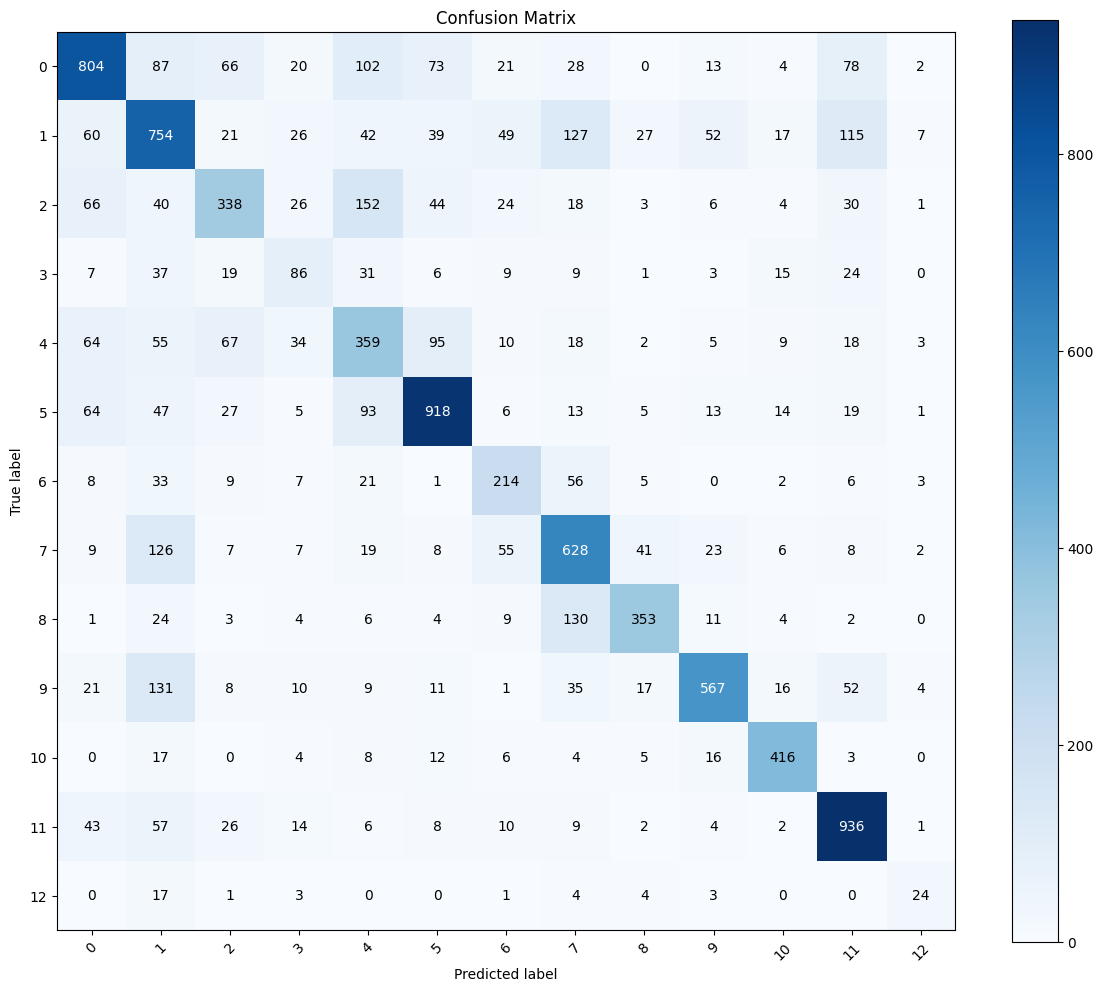

In [1]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [804, 87, 66, 20, 102, 73, 21, 28, 0, 13, 4, 78, 2],
    [60, 754, 21, 26, 42, 39, 49, 127, 27, 52, 17, 115, 7],
    [66, 40, 338, 26, 152, 44, 24, 18, 3, 6, 4, 30, 1],
    [7, 37, 19, 86, 31, 6, 9, 9, 1, 3, 15, 24, 0],
    [64, 55, 67, 34, 359, 95, 10, 18, 2, 5, 9, 18, 3],
    [64, 47, 27, 5, 93, 918, 6, 13, 5, 13, 14, 19, 1],
    [8, 33, 9, 7, 21, 1, 214, 56, 5, 0, 2, 6, 3],
    [9, 126, 7, 7, 19, 8, 55, 628, 41, 23, 6, 8, 2],
    [1, 24, 3, 4, 6, 4, 9, 130, 353, 11, 4, 2, 0],
    [21, 131, 8, 10, 9, 11, 1, 35, 17, 567, 16, 52, 4],
    [0, 17, 0, 4, 8, 12, 6, 4, 5, 16, 416, 3, 0],
    [43, 57, 26, 14, 6, 8, 10, 9, 2, 4, 2, 936, 1],
    [0, 17, 1, 3, 0, 0, 1, 4, 4, 3, 0, 0, 24]
])

fig, ax = plt.subplots(figsize=(12,10))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=np.arange(13), yticklabels=np.arange(13),
       title="Confusion Matrix",
       ylabel='True label',
       xlabel='Predicted label')

plt.xticks(rotation=45)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()



The resulting plot visualizes the model's performance by showing, for each true class, how often the model predicted each possible label.


## Summary

- We tested multiple improvements: scheduler, augmentation, optimizer, class balancing, error analysis, and early stopping.
- The best model achieves ~64% accuracy on a challenging 13-class task.
- The confusion matrix and error report help identify where the model still makes mistakes and where further improvements may be possible.
